# Estimated Costs & Valuations



In [2]:
import json
import math
import os
import re
from os import listdir

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pyproj
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from shapely.geometry import Point, Polygon, box
from unidecode import unidecode

## Constants
m2_to_ha = 0.0001
x_resolution, y_resolution = 10, 10


def dollar_to_decimal(value):
    if isinstance(value, float):
        return value  # If the value is already a float, return it as is.
    if isinstance(value, str):
        if value == "No data":
            return value
        # Clean the string using a regular expression to remove non-numeric, non-decimal, and non-minus characters.
        cleaned_str = re.sub(r"[^\d.-]", "", value.strip())
        # Check if the cleaned string is a valid decimal number
        if re.match(r"^-?\d+(\.\d+)?$", cleaned_str):
            try:
                decimal_value = float(cleaned_str)
                return decimal_value
            except ValueError:
                raise ValueError(
                    f"Invalid dollar figure after cleaning: {cleaned_str} from original {value}"
                )

    return None  # Return None for invalid inputs, empty strings, or non-string/non-float data

# Load Prerequisites

## Area of interest

CPU times: total: 27.9 s
Wall time: 28.3 s


<Axes: >

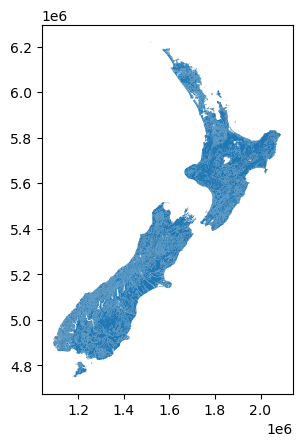

In [2]:
%%time
ecosystem_proj = gpd.read_file("../BaseLayersEco-index/Eco-index_EcosystemProjector_Details_v260924.gpkg")
# Note: aoi file needs to have the 'EcosystemType'/PNVWmacron  for costings:
ecosystem_proj["PNVW"] = ecosystem_proj["ExpectedEcosystemType"].apply(unidecode)
ecosystem_proj.plot()

In [21]:
%%time
snapshot = gpd.read_file('../BaseLayersEco-index/Eco-index_LandCoverSnapshot_Details_v290924.gpkg')


CPU times: total: 10.6 s
Wall time: 12.7 s


In [24]:
mature_regen = snapshot[snapshot['LandCoverStatus'].isin(['Regenerating Ecosystems', 'Mature Ecosystems'])].copy()
mature_regen.sindex

In [4]:
%%time
# restorable.sindex
# restorable_diss = restorable[['geometry']].dissolve()
# restorable_diss = restorable_diss.explode()
# restorable_diss.head(2)
# restorable_diss.to_file('../BaseLayersEco-index/Eco-index_RestorableAreas_v290824.gpkg')

restorable_diss = gpd.read_file('../BaseLayersEco-index/Eco-index_RestorableAreas_v290824.gpkg')

CPU times: total: 891 ms
Wall time: 1.09 s


In [8]:
restorable_diss.sindex

In [3]:
%%time
# ecosystem_proj.sindex
# restorable_diss.sindex
# ecosystem_proj_restorable = ecosystem_proj.overlay(restorable_diss)
# ecosystem_proj_restorable.to_file("../BaseLayersEco-index/Eco-index_EcosystemProjector_Details__Restorable_v260924.gpkg")

ecosystem_proj_restorable = gpd.read_file("../BaseLayersEco-index/Eco-index_EcosystemProjector_Details__Restorable_v260924.gpkg")

CPU times: total: 1.53 s
Wall time: 1.73 s


<Axes: >

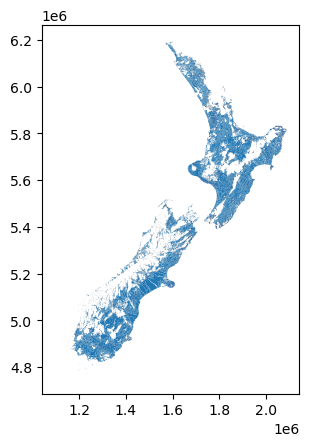

In [4]:
ecosystem_proj_restorable.plot()

# Existing Areas VALUATIONS

In [42]:
val_mapping = pd.read_csv(
    "../BaseLayersEco-index/TableOfTruth_LCDB_Mapping.csv"
)
val_mapping = val_mapping[
    [
        "LCDB_5 Land cover class",
        "LCDB Wetland context",
        "Land cover status",
        "ECOSYSTEM VALUATION BIOME USE THIS FOR Ecosystem Services Valuer",
    ]
]

anys = val_mapping.loc[val_mapping["LCDB Wetland context"] == "any", :].copy()
anys["LCDB Wetland context"] = anys.shape[0] * [["Yes", "No"]]

val_mapping = pd.concat(
    [
        anys.explode("LCDB Wetland context"),  # the ones we have added
        val_mapping[val_mapping["LCDB Wetland context"] != "any"],
    ]
).reset_index(drop=True)

val_mappping_rename = {
    "LCDB_5 Land cover class": "LCDB_5 Land cover class",
    "LCDB Wetland context": "LCDB Wetland context",
    "Land cover status": "Land cover status",
    "ECOSYSTEM VALUATION BIOME USE THIS FOR Ecosystem Services Valuer": "ECOSYSTEM VALUATION BIOME",
}
val_mapping = val_mapping.rename(val_mappping_rename, axis=1)
val_mapping["LCDB Wetland context"] = val_mapping["LCDB Wetland context"].str.lower()
valuations_ena = valuations.merge(
    val_mapping, on="ECOSYSTEM VALUATION BIOME", how="left"
)

ena_vals = mature_regen.drop('EcosystemValuationBiome', axis=1).merge(
    valuations_ena,
    left_on=["LCDBLandCoverClass", "LCDBWetlandContext"],
    right_on=["LCDB_5 Land cover class", "LCDB Wetland context"],
    how="left",
)
print(mature_regen.shape[0], ena_vals.shape[0])

298142 298142


In [36]:
## LCDB values we don't have valuations for:
ena_vals[ena_vals["LCDB Wetland context"].isna()][
    ["LCDBLandCoverClass", "LCDBWetlandContext"]
].drop_duplicates()


#### 'Sand or Gravel' is expected to be here: 'NO SUITABLE BIOME - USE ZEROS'

,LCDBLandCoverClass,LCDBWetlandContext
40,Gravel or Rock,no
46,Sand or Gravel,no
2613,Landslide,no
24495,Gravel or Rock,yes


In [37]:
drop_cols =[col for col in [
    "LCDB_5 Land cover class",
    "LCDB Wetland context",
    "Land cover status", 'Realm',
       'ExistingNaturalArea',
    # "ECOSYSTEM VALUATION BIOME",
] if col in ena_vals.columns]
ena_vals = ena_vals.drop(drop_cols, axis=1)

rename_cols = {
    "Name_2018": "LCDB Land cover class",
    "Wetland_18": "LCDB Wetland context",
    "ECOSYSTEM VALUATION BIOME":"EcosystemValuationBiome"
}
ena_vals = ena_vals.rename(rename_cols, axis=1)

# new_cols = [col.replace('per ha', 'per ha per annum') for col in ena_vals.columns]
# ena_vals.columns = new_cols
# ena_vals[~ena_vals["EcosystemValuationBiome"].isna()].to_file(
#     "dummy.gpkg"
# )

In [44]:
ena_vals.columns

Index(['LCDBLandCoverClass', 'LCDBWetlandContext', 'LandCoverStatus', 'Realm',
       'ExistingNaturalArea', 'geometry', 'ECOSYSTEM VALUATION BIOME',
       'ES: Food (per ha per annum)', 'ES: Water (per ha per annum)',
       'ES: Raw materials (per ha per annum)',
       'ES: Genetic resources (per ha per annum)',
       'ES: Medicinal resources (per ha per annum)',
       'ES: Ornamental resources (per ha per annum)',
       'ES: Air quality regulation (per ha per annum)',
       'ES: Climate regulation (per ha per annum)',
       'ES: Moderation of extreme events (per ha per annum)',
       'ES: Regulation of water flows (per ha per annum)',
       'ES: Waste treatment (per ha per annum)',
       'ES: Erosion prevention (per ha per annum)',
       'ES: Maintenance of soil fertility (per ha per annum)',
       'ES: Pollination (per ha per annum)',
       'ES: Biological control (per ha per annum)',
       'ES: Maintenance of life cycles (per ha per annum)',
       'ES: Maintenance o

In [47]:
ena_vals.to_file('../BaseLayersNavigator/B01_EcosystemServicesValuer/Eco-index_EcosystemServicesValuer_ExistingAreas_20240926.gpkg')

# New Areas VALUATIONS

In [6]:
valuations = pd.read_csv(
    "../BaseLayersEco-index/TableOfTruth_Valuations.csv"
).iloc[:26, :]
valuations = valuations.drop("Coastal US$ AND NOT TODAY VALUE", axis=1)
cols = [col.strip() for col in valuations.columns]
valuations.columns = cols

valuations = valuations.set_index(
    "Economic values for ecosystem services: A global synthesis and way forward"
).T

valuations = valuations.drop(
    [
        "Mean values (NZD 2024/ha/year) per ecosystem service – biome combination.",
        "https://www.esvd.info/classifications   ESVD 2.0 Biomes",
    ],
    axis=1,
)
cols = [f"ES: {col} (per ha per annum)" for col in valuations.columns]
valuations.columns = cols

valuations = valuations.rename(
    {"ES: SUM OF ALL ES VALUES (per ha)": "ES: Total Ecosystem Services (per ha)"},
    axis=1,
)

valuations = valuations.reset_index().rename(
    {"index": "ECOSYSTEM VALUATION BIOME"}, axis=1
)

dollar_cols = [
    col for col in valuations if col not in ["PNVW", "ECOSYSTEM VALUATION BIOME"]
]
for col in dollar_cols:
    valuations[col] = valuations[col].apply(dollar_to_decimal)


val_mapping = pd.read_csv(
    "../BaseLayersEco-index/TableOfTruth_PNVW_Mapping.csv"
)
val_mapping["PNVW"] = val_mapping[
    "Potential Natural Vegetation and Wetland Type"
].apply(unidecode)
val_mapping["ECOSYSTEM VALUATION BIOME"] = val_mapping[
    "ECOSYSTEM VALUATION BIOME USE THIS FOR Ecosystem Services Valuer"
]

## Fi typo 
val_mapping['ECOSYSTEM VALUATION BIOME'] = val_mapping['ECOSYSTEM VALUATION BIOME'].str.replace('\n', '')

val_mapping = val_mapping[["PNVW", "ECOSYSTEM VALUATION BIOME"]].copy()

# Fix extra space
val_mapping.loc[val_mapping.PNVW == "Hall's  totara-miro/kamahi-southern rata broadleaf forest", 'PNVW'] = "Hall's totara-miro/kamahi-southern rata broadleaf forest"



valuations_pnvw = valuations.merge(
    val_mapping, on="ECOSYSTEM VALUATION BIOME", how="left"
) 

In [15]:
valuations_pnvw.columns.value_counts()

ECOSYSTEM VALUATION BIOME                                          1
ES: Food (per ha per annum)                                        1
ES: SUM OF ALL ES VALUES (per ha per annum)                        1
ES: Information for cognitive development (per ha per annum)       1
ES: Spiritual experience (per ha per annum)                        1
ES: Inspiration for culture, art and design (per ha per annum)     1
ES: Existence, bequest values (per ha per annum)                   1
ES: Opportunities for recreation and tourism (per ha per annum)    1
ES: Aesthetic information (per ha per annum)                       1
ES: Maintenance of genetic diversity (per ha per annum)            1
ES: Maintenance of life cycles (per ha per annum)                  1
ES: Biological control (per ha per annum)                          1
ES: Pollination (per ha per annum)                                 1
ES: Maintenance of soil fertility (per ha per annum)               1
ES: Erosion prevention (per ha per

In [18]:
# # Then join to the geometry
ecosystem_proj_restorable_vals = ecosystem_proj_restorable.merge(valuations_pnvw.drop('ECOSYSTEM VALUATION BIOME', axis=1), on="PNVW", how="left")

# CHeck only unclassified has null values
ecosystem_proj_restorable_vals[
        ecosystem_proj_restorable_vals['ES: Food (per ha per annum)'].isna()
    ].PNVW.unique()

# Tidy
ecosystem_proj_restorable_vals = (ecosystem_proj_restorable_vals
                                  .drop('PNVW', axis=1)
                                  .rename({'ECOSYSTEM VALUATION BIOME':'EcosystemValuationBiome'}, axis=1)
                                 )

In [20]:
ecosystem_proj_restorable_vals.to_file('../BaseLayersNavigator/B01_EcosystemServicesValuer/Eco-index_EcosystemServicesValuer_ReconstructionAreas_20240926.gpkg')

# Review and Plot

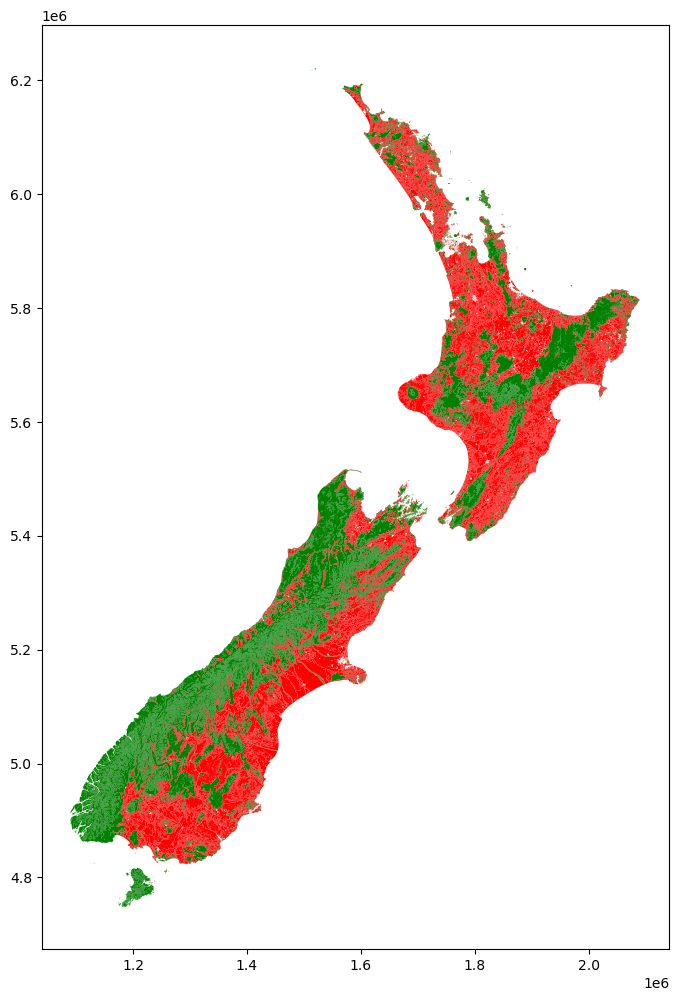

In [48]:
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt

val_existing = gpd.read_file('../BaseLayersNavigator/B01_EcosystemServicesValuer/Eco-index_EcosystemServicesValuer_ExistingAreas_20240926.gpkg')
val_existing.head()
val_recon = gpd.read_file('../BaseLayersNavigator/B01_EcosystemServicesValuer/Eco-index_EcosystemServicesValuer_ReconstructionAreas_20240926.gpkg')
val_recon.head()

fig, ax = plt.subplots(figsize=(12,12))
val_existing.plot(ax=ax, color='green')
val_recon.plot(ax=ax, color='red')
plt.show()